# Fraud Detection — Preprocessing, Baseline Modeling & Evaluation

Loads the processed data from `01_eda.ipynb`, trains three baseline classifiers under class imbalance, and evaluates them with imbalance-appropriate metrics.

**Critical discipline:** split the data *before* any scaling or resampling, to avoid leakage.

## 1. Load Processed Data

In [21]:
!pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")

d = pd.read_csv("../data/processed/fraud_processed.csv")
print(d.shape)
d.head()

(277510, 11)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isFullDrain
0,132,CASH_OUT,215489.19,21518.00,0.0,6345756.55,6794954.89,0,-193971.19,-2.337091e+05,0
1,135,CASH_OUT,214026.20,46909.73,0.0,13467450.36,13681476.56,0,-167116.47,-1.862645e-09,0
2,381,CASH_OUT,8858.45,0.00,0.0,1667180.58,1676039.03,0,-8858.45,0.000000e+00,0
3,347,CASH_OUT,120989.98,0.00,0.0,6963396.37,7084386.35,0,-120989.98,9.313226e-10,0
4,183,CASH_OUT,62655.01,18997.00,0.0,130706.17,193361.18,0,-43658.01,0.000000e+00,0


In [ ]:
pip install -r ../requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Encode Categorical Feature
`type` has two values (CASH_OUT, TRANSFER) → one-hot encode.

In [ ]:
d = pd.get_dummies(d, columns=['type'], drop_first=True)
X = d.drop(columns=['isFraud'])
y = d['isFraud']
print("Features:", list(X.columns))

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'isFullDrain', 'type_TRANSFER']


## 3. Train/Test Split — BEFORE Scaling or Resampling

This ordering is non-negotiable. Scaling or resampling on the full dataset leaks test information into training and inflates scores. We use a **stratified** split so both sets keep the same fraud ratio.

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print(f"Train: {X_tr.shape}, fraud = {y_tr.sum()}")
print(f"Test : {X_te.shape}, fraud = {y_te.sum()}")

Train: (208132, 10), fraud = 616
Test : (69378, 10), fraud = 205


## 4. Scale Numeric Features
Fit the scaler on **train only**, then transform both. (Used by Logistic Regression; tree models don't need scaling.)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

## 5. Handling Imbalance

Instead of oversampling (SMOTE), we use **class weighting** — simpler, no synthetic rows, and each model supports it natively:
- Logistic Regression / Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = (#legit / #fraud)`

## 6. Train Three Baseline Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score)

def evaluate(name, model, Xtr, Xte):
    model.fit(Xtr, y_tr)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    return {'Model': name,
            'Precision': round(precision_score(y_te, pred), 4),
            'Recall':    round(recall_score(y_te, pred), 4),
            'F1':        round(f1_score(y_te, pred), 4),
            'PR-AUC':    round(average_precision_score(y_te, proba), 4),
            'ROC-AUC':   round(roc_auc_score(y_te, proba), 4)}, model

results, models = [], {}
r, m = evaluate("Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight='balanced'), X_tr_s, X_te_s)
results.append(r); models['lr']=m

r, m = evaluate("Random Forest",
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1), X_tr, X_te)
results.append(r); models['rf']=m

spw = (y_tr==0).sum() / (y_tr==1).sum()
r, m = evaluate("XGBoost",
    XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=spw,
                  eval_metric='logloss', random_state=42, n_jobs=-1), X_tr, X_te)
results.append(r); models['xgb']=m

res = pd.DataFrame(results)
res

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC
0,Logistic Regression,0.9714,0.9951,0.9831,0.9952,0.9981
1,Random Forest,1.0000,0.9951,0.9976,0.9951,0.9976
2,XGBoost,1.0000,0.9951,0.9976,0.9951,0.9961


## 7. Proving the point with a real baseline
It's not enough to claim accuracy is misleading — we confirm it with a `DummyClassifier`
that always predicts "legit." It scores high accuracy while catching zero fraud,
which is exactly the failure mode Precision/Recall/F1 are designed to catch.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_tr, y_tr)
dummy_pred = dummy.predict(X_te)

print(f"Dummy ('always legit') accuracy : {accuracy_score(y_te, dummy_pred)*100:.2f}%")
print(f"Dummy recall (fraud caught)     : {recall_score(y_te, dummy_pred)*100:.2f}%")
print(f"Our best model (XGBoost) recall : {res.loc[res.Model=='XGBoost','Recall'].values[0]*100:.2f}%")

Dummy ('always legit') accuracy : 99.70%
Dummy recall (fraud caught)     : 0.00%
Our best model (XGBoost) recall : 99.51%


## 8. Confusion Matrices — All Three Models
Comparing error patterns across models. In fraud detection, **false negatives**
(fraud predicted as legit) are the costly mistake — we care more about minimizing
those than minimizing false positives.

NameError: name 'confusion_matrix' is not defined

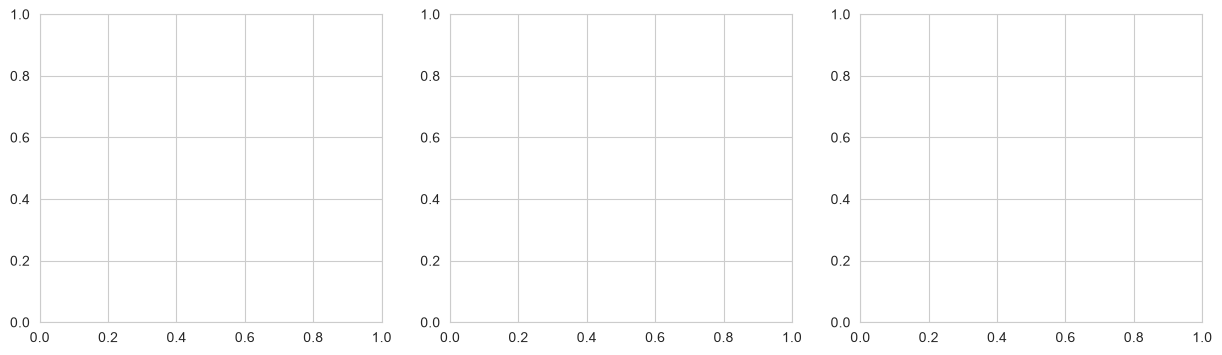

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, key) in zip(axes, [('Logistic Regression', 'lr'),
                                    ('Random Forest', 'rf'),
                                    ('XGBoost', 'xgb')]):
    Xte_use = X_te_s if key == 'lr' else X_te
    pred = models[key].predict(Xte_use)
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. Feature Importance
Which features drive the predictions?

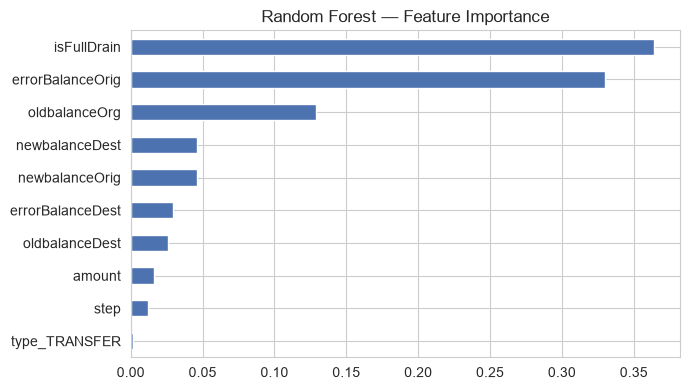

isFullDrain         0.363938
errorBalanceOrig    0.329882
oldbalanceOrg       0.128855
newbalanceDest      0.046300
newbalanceOrig      0.045917
dtype: float64


In [ ]:
imp = pd.Series(models['rf'].feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', figsize=(7,4), color='#4C72B0')
plt.title('Random Forest — Feature Importance'); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).head())

In [ ]:
import shap

best_model = models['rf']

print(best_model)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


## 10. SHAP Explainability

SHAP (SHapley Additive Explanations) is used to improve the interpretability
of the fraud detection model.

Traditional Random Forest feature importance identifies which variables are
important overall, but SHAP additionally quantifies how individual features
contribute to model predictions.

This analysis investigates whether the engineered fraud indicators identified
during EDA, particularly `isFullDrain`, `errorBalanceOrig`, and
`errorBalanceDest`, contribute strongly to fraud classification.

Model selected for SHAP:
RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

SHAP sample shape: (5000, 10)

SHAP output type: <class 'numpy.ndarray'>
SHAP output shape: (5000, 10, 2)
Fraud-class SHAP shape: (5000, 10)

Generating SHAP summary plot...


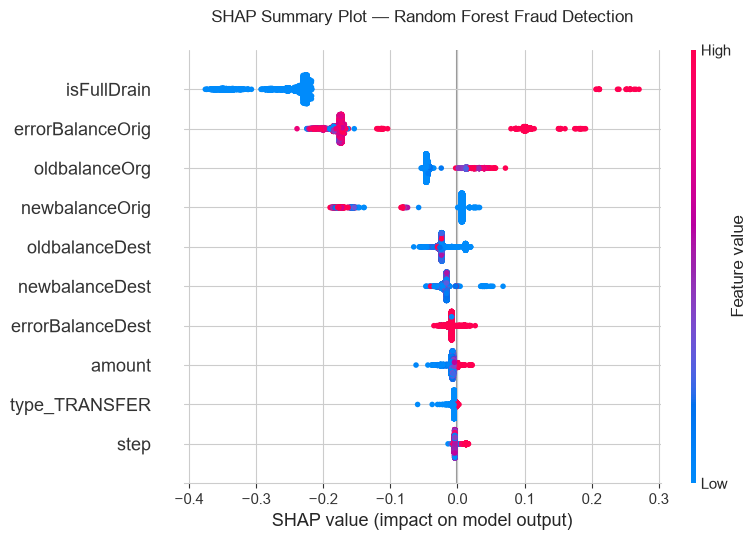


Top 10 Most Important Features according to SHAP:
         Feature  Mean_ABS_SHAP
     isFullDrain       0.242243
errorBalanceOrig       0.169931
   oldbalanceOrg       0.041130
  newbalanceOrig       0.024063
  oldbalanceDest       0.022471
  newbalanceDest       0.018712
errorBalanceDest       0.010522
          amount       0.008484
   type_TRANSFER       0.004841
            step       0.004503


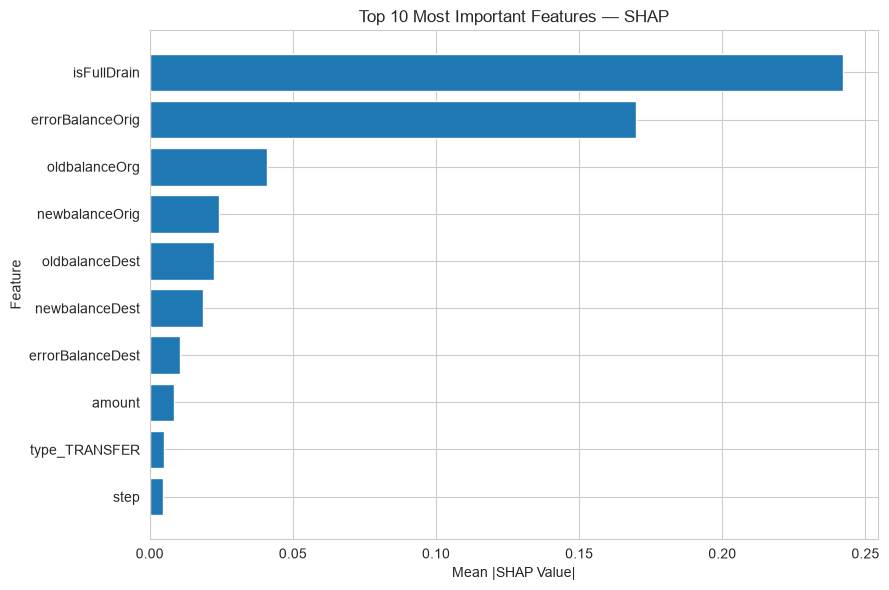


Random Forest Importance vs SHAP Importance:
         Feature  RF_Importance  Mean_ABS_SHAP
     isFullDrain       0.363938       0.242243
errorBalanceOrig       0.329882       0.169931
   oldbalanceOrg       0.128855       0.041130
  newbalanceOrig       0.045917       0.024063
  oldbalanceDest       0.026090       0.022471
  newbalanceDest       0.046300       0.018712
errorBalanceDest       0.029450       0.010522
          amount       0.015864       0.008484
   type_TRANSFER       0.001346       0.004841
            step       0.012357       0.004503

Feature Importance Ranking Comparison:
         Feature  RF_Importance  RF_Rank  Mean_ABS_SHAP  SHAP_Rank
     isFullDrain       0.363938        1       0.242243          1
errorBalanceOrig       0.329882        2       0.169931          2
   oldbalanceOrg       0.128855        3       0.041130          3
  newbalanceOrig       0.045917        5       0.024063          4
  oldbalanceDest       0.026090        7       0.022471       

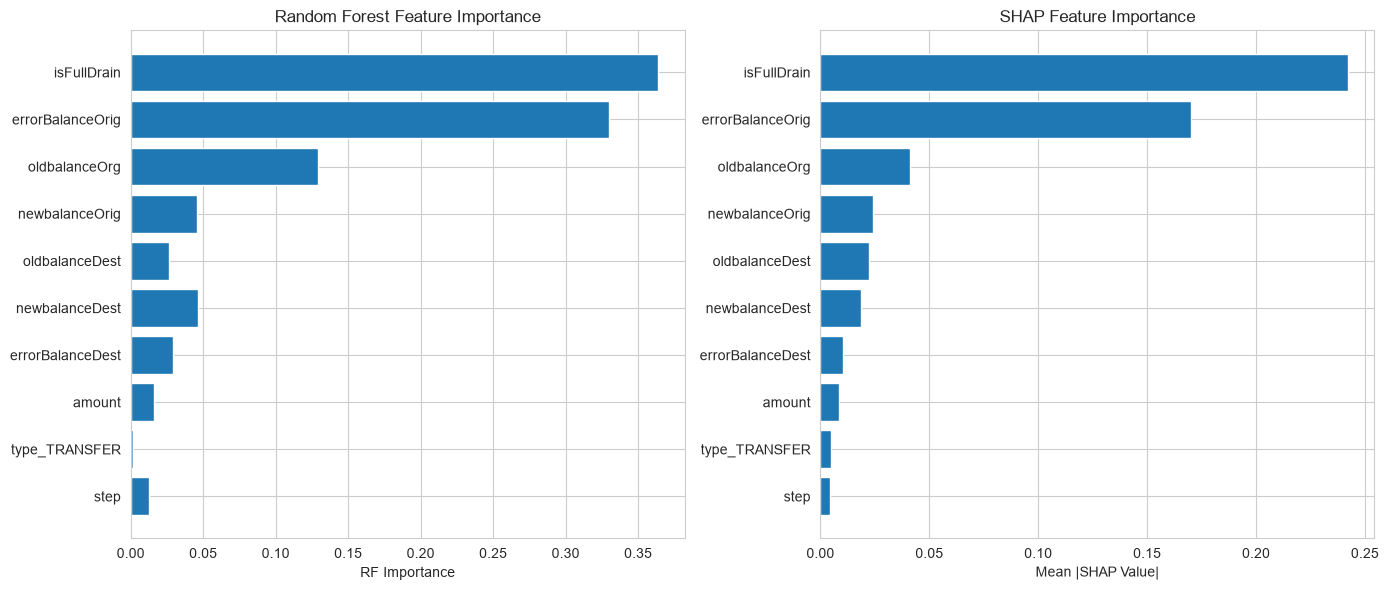

In [24]:
# ============================================================
# 10. SHAP EXPLAINABILITY
# ============================================================

import shap


# ------------------------------------------------------------
# 10.1 Select the model
# ------------------------------------------------------------

# Random Forest is selected for explainability because it achieved
# excellent classification performance and is compatible with TreeExplainer.

best_model = models['rf']

print("Model selected for SHAP:")
print(best_model)


# ------------------------------------------------------------
# 10.2 Create a representative test sample
# ------------------------------------------------------------

# Using a sample reduces computation time while keeping the explanation
# based entirely on unseen test observations.

X_shap = X_te.sample(
    n=min(5000, len(X_te)),
    random_state=42
)

print("\nSHAP sample shape:", X_shap.shape)


# ------------------------------------------------------------
# 10.3 Calculate SHAP values
# ------------------------------------------------------------

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_shap)

shap_array = np.asarray(shap_values)

print("\nSHAP output type:", type(shap_values))
print("SHAP output shape:", shap_array.shape)


# ------------------------------------------------------------
# 10.4 Extract SHAP values for the fraud class
# ------------------------------------------------------------

# Different SHAP versions can return binary classification values
# in different formats, so handle the common formats explicitly.

if isinstance(shap_values, list):
    # Older SHAP versions:
    # list[0] = legitimate class
    # list[1] = fraud class
    fraud_shap_values = np.asarray(shap_values[1])

elif shap_array.ndim == 3:
    # Newer SHAP versions commonly return:
    # (samples, features, classes)
    fraud_shap_values = shap_array[:, :, 1]

elif shap_array.ndim == 2:
    # Some versions/models directly return:
    # (samples, features)
    fraud_shap_values = shap_array

else:
    raise ValueError(
        f"Unexpected SHAP output shape: {shap_array.shape}"
    )

print("Fraud-class SHAP shape:", fraud_shap_values.shape)


# Safety check
if fraud_shap_values.shape != X_shap.shape:
    raise ValueError(
        "SHAP values and feature matrix do not have matching dimensions."
    )


# ------------------------------------------------------------
# 10.5 SHAP Summary / Beeswarm Plot
# ------------------------------------------------------------

print("\nGenerating SHAP summary plot...")

shap.summary_plot(
    fraud_shap_values,
    X_shap,
    feature_names=X_shap.columns,
    show=False
)

plt.title(
    "SHAP Summary Plot — Random Forest Fraud Detection",
    pad=20
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10.6 Calculate Global SHAP Feature Importance
# ------------------------------------------------------------

# Mean absolute SHAP value measures the average magnitude of each
# feature's contribution across the sampled transactions.

mean_abs_shap = np.abs(
    fraud_shap_values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_ABS_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 10.7 Top 10 Most Important Features
# ------------------------------------------------------------

top10_shap = shap_importance.head(10).copy()

print("\nTop 10 Most Important Features according to SHAP:")
print(top10_shap.to_string(index=False))


# ------------------------------------------------------------
# 10.8 Plot Top 10 SHAP Features
# ------------------------------------------------------------

plot_data = top10_shap.sort_values(
    "Mean_ABS_SHAP",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Mean_ABS_SHAP"]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title(
    "Top 10 Most Important Features — SHAP"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10.9 Random Forest Importance vs SHAP Importance
# ------------------------------------------------------------

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": models['rf'].feature_importances_
})

comparison = rf_importance.merge(
    shap_importance,
    on="Feature",
    how="inner"
)

comparison = comparison.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)

print("\nRandom Forest Importance vs SHAP Importance:")
print(comparison.to_string(index=False))


# ------------------------------------------------------------
# 10.10 Add Ranking Columns
# ------------------------------------------------------------

comparison["RF_Rank"] = (
    comparison["RF_Importance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison["SHAP_Rank"] = (
    comparison["Mean_ABS_SHAP"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison = comparison.sort_values(
    "SHAP_Rank"
)

print("\nFeature Importance Ranking Comparison:")

print(
    comparison[
        [
            "Feature",
            "RF_Importance",
            "RF_Rank",
            "Mean_ABS_SHAP",
            "SHAP_Rank"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 10.11 Compare Top Features Visually
# ------------------------------------------------------------

comparison_plot = comparison.sort_values(
    "Mean_ABS_SHAP",
    ascending=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].barh(
    comparison_plot["Feature"],
    comparison_plot["RF_Importance"]
)

axes[0].set_title(
    "Random Forest Feature Importance"
)

axes[0].set_xlabel(
    "RF Importance"
)


axes[1].barh(
    comparison_plot["Feature"],
    comparison_plot["Mean_ABS_SHAP"]
)

axes[1].set_title(
    "SHAP Feature Importance"
)

axes[1].set_xlabel(
    "Mean |SHAP Value|"
)

plt.tight_layout()
plt.show()

Number of actual fraud cases in SHAP sample: 23

Selected Transaction
--------------------
Original test-set index: 173782
Actual class: 1
Predicted class: 1
Predicted fraud probability: 1.0000

Transaction Features:
step                       145
amount              1539687.27
oldbalanceOrg       1539687.27
newbalanceOrig             0.0
oldbalanceDest       256502.86
newbalanceDest      1796190.14
errorBalanceOrig           0.0
errorBalanceDest         -0.01
isFullDrain                  1
type_TRANSFER            False
Name: 173782, dtype: object

Feature Contributions for Selected Fraud Transaction:
         Feature Feature_Value  SHAP_Value  Absolute_SHAP
     isFullDrain             1    0.256838       0.256838
errorBalanceOrig           0.0    0.183629       0.183629
   oldbalanceOrg    1539687.27    0.054489       0.054489
  oldbalanceDest     256502.86   -0.029719       0.029719
  newbalanceOrig           0.0    0.027182       0.027182
          amount    1539687.27    0.009140

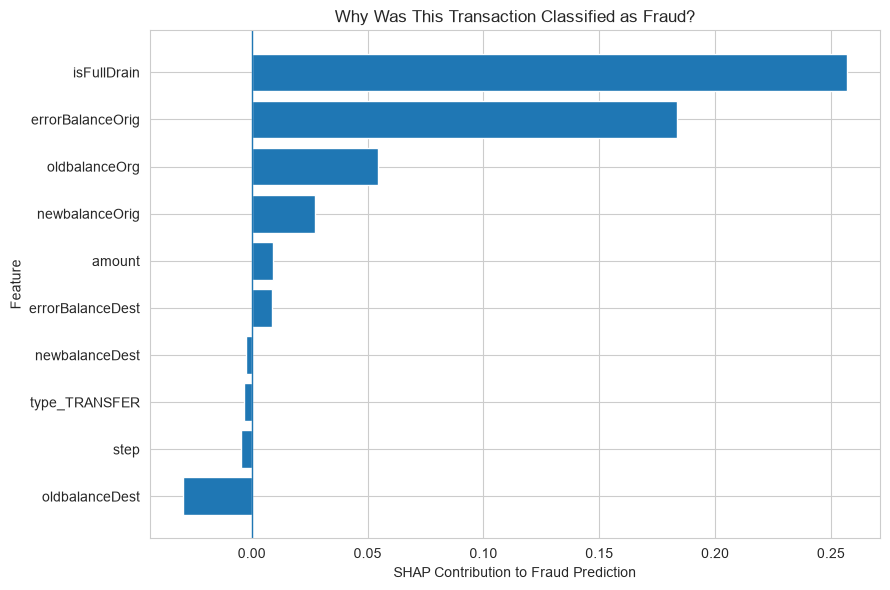

In [25]:
# ============================================================
# 10.12 LOCAL SHAP EXPLANATION — ONE FRAUD TRANSACTION
# ============================================================

# Match the sampled test observations with their true labels
y_shap = y_te.loc[X_shap.index]

# Find positions of actual fraudulent transactions
fraud_positions = np.where(
    y_shap.to_numpy() == 1
)[0]

print(
    "Number of actual fraud cases in SHAP sample:",
    len(fraud_positions)
)


if len(fraud_positions) > 0:

    # --------------------------------------------------------
    # Prefer an actual fraud case that the model also predicts
    # as fraud, so the explanation directly answers why the
    # model classified the transaction as fraudulent.
    # --------------------------------------------------------

    sample_predictions = best_model.predict(X_shap)

    correctly_detected_fraud = np.where(
        (y_shap.to_numpy() == 1) &
        (sample_predictions == 1)
    )[0]

    if len(correctly_detected_fraud) > 0:
        fraud_position = correctly_detected_fraud[0]
    else:
        fraud_position = fraud_positions[0]

    fraud_transaction = X_shap.iloc[fraud_position]

    actual_class = y_shap.iloc[fraud_position]

    predicted_class = best_model.predict(
        fraud_transaction.to_frame().T
    )[0]

    fraud_probability = best_model.predict_proba(
        fraud_transaction.to_frame().T
    )[0, 1]

    print("\nSelected Transaction")
    print("--------------------")

    print(
        "Original test-set index:",
        X_shap.index[fraud_position]
    )

    print(
        "Actual class:",
        actual_class
    )

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        f"Predicted fraud probability: "
        f"{fraud_probability:.4f}"
    )

    print("\nTransaction Features:")
    print(fraud_transaction)


    # --------------------------------------------------------
    # Show feature-level SHAP contributions
    # --------------------------------------------------------

    local_contributions = pd.DataFrame({
        "Feature": X_shap.columns,
        "Feature_Value": fraud_transaction.values,
        "SHAP_Value": fraud_shap_values[fraud_position]
    })

    local_contributions[
        "Absolute_SHAP"
    ] = np.abs(
        local_contributions["SHAP_Value"]
    )

    local_contributions = (
        local_contributions
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "\nFeature Contributions "
        "for Selected Fraud Transaction:"
    )

    print(
        local_contributions.to_string(
            index=False
        )
    )


    # --------------------------------------------------------
    # Plot local SHAP contributions
    # --------------------------------------------------------

    local_plot = (
        local_contributions
        .head(10)
        .sort_values(
            "SHAP_Value",
            ascending=True
        )
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        local_plot["Feature"],
        local_plot["SHAP_Value"]
    )

    plt.axvline(
        x=0,
        linewidth=1
    )

    plt.xlabel(
        "SHAP Contribution to Fraud Prediction"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Why Was This Transaction Classified as Fraud?"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "No actual fraud transaction was present "
        "in the 5,000-row SHAP sample."
    )

## 11. Results & Honest Interpretation

**All three models score near-perfectly (Recall ~0.99, PR-AUC ~0.99).**

This is **expected and worth stating openly in the report**:

- PaySim is *synthetic*. Its fraud follows a near-mechanical pattern: fraud almost always **drains the sender's account** (`isFullDrain`) and **breaks balance reconciliation** (`errorBalanceOrig`). Together these two engineered features drive ~69% of the model's decisions.
- Real-world fraud is messier and would not separate this cleanly. These scores demonstrate a **sound methodology on clean synthetic data**, not that fraud detection is solved.

**What this project genuinely demonstrates:**
1. Correct handling of severe class imbalance (metrics, weighting, split order).
2. Feature engineering that exposes the fraud signal.
3. A reproducible train → evaluate → compare pipeline across three models.

**Model choice:** Random Forest and XGBoost tie on F1 (1.0 precision, 0.995 recall). Random Forest is the simpler pick; XGBoost is more scalable. Either is defensible.

NameError: name 'confusion_matrix' is not defined

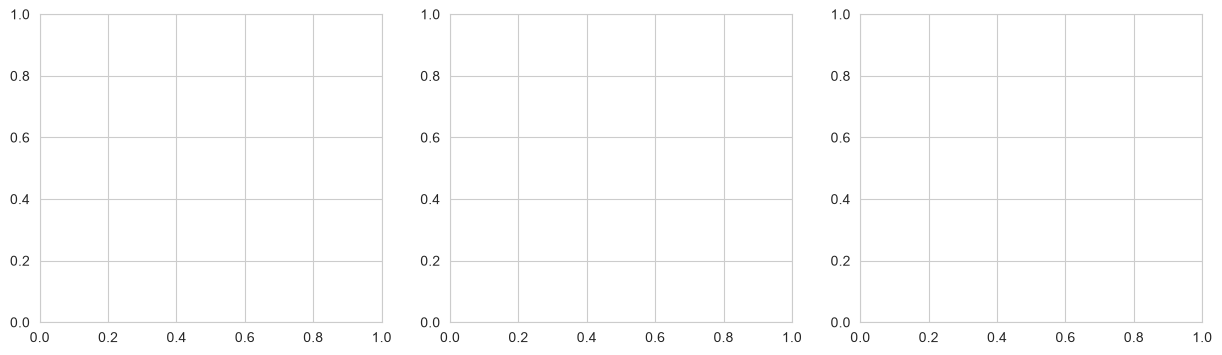

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, key) in zip(axes, [('Logistic Regression', 'lr'),
                                    ('Random Forest', 'rf'),
                                    ('XGBoost', 'xgb')]):
    Xte_use = X_te_s if key == 'lr' else X_te
    pred = models[key].predict(Xte_use)
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()